In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

import sys

Liste_features_simple = ["Sex",
                         "Age"	, # poly lineariser sur 0 1
                         "Time H-ICU"	,
                         "TIME SYMPTOMES-ICU"	,
                         "Time  DG-ICU", 
                         "Hem_mal"	,# a transformer par dic
                         "Dis_status HEM" ,# a transformer par dic
                         "HSCT_BMT",#dicoto allo auto
                         "GvHD"	, # ?
                         "Sys_dis",
                         "Solid_tumor"	,
                         "Organ_transpl"	,
                         #"Organ_transpl_spec"	,# peut se faire
                         "Drug_induced"	, # enlever les " "
                         "Chemotherapy"	,# enlever les " "
                         "Ibr_Flu_Met"	,
                         "Immuno_drugs"	,
                         "Tar_ther"	,
                         "Immunotherapy"	,
                         "Carttcells"	,
                         "Steroids_YN",
                         "Prophylaxis_pneumocystis",
                         "Prophylaxis_antifungal",
                         "Prophylaxis_bacterial"	,
                         "Prophylaxis_viral",
                         "Vaccins#Flu",
                         "Vaccins#COVID",
                         "Vaccins#Other",
                         "SOFA_score", # lineariser
                         "Resp_rate", # faire un score catégoriser avec intubation/Sp02
                         "SpO2",
                         "Temp", #a linéariser
                         "Neutrophils", #a catégoriser + clean
                         "Leukocytes",

]


# Charger le fichier Excel
df = pd.read_excel('D:/EFRAIM3 JD VANCE.xlsx')
# statistiques
features_etiology =[
                    'Etiology_Bacterial infection_Definitive diagnosis',
                    'Etiology_Viral infection_Definitive diagnosis',
                    'Etiology_Invasive pulmonary aspergillosis_Definitive diagnosis',
                    'Etiology_Pneumocystis jirovecii infection_Definitive diagnosis',
                    'Etiology_Mucorales_Definitive diagnosis',
                    'Etiology_Other fungal (specify below)_Definitive diagnosis',
                    'Etiology_Other infection (specify below)_Definitive diagnosis',
                    'Etiology_Cardiogenic pulmonary oedema_Definitive diagnosis',
                    'Etiology_Drug related_Definitive diagnosis',
                    'Etiology_Disease-related infiltrates_Definitive diagnosis',
                    'Etiology_Transfusion-related acute lung injury_Definitive diagnosis',
                    'Etiology_Other causes (specify below)_Definitive diagnosis',
                    'Etiology_Undetermined cause_Definitive diagnosis'
                    ]

features_radiology_dysfunction = ["Alveolar_xray",
                      	"Interst_xray",
                        "Pleural_eff",
                        "Quad_no",
                    	"Excavation",
                        "Fibrosis"	,
                        "Nodules"	,
                        "Pneumothorax"	,
                        "Cardiomegaly",
                        'Septal_line'	,
                        'CT_Pleural_eff'	,
                        'Halo_sign'	,
                        'CT_Excavation'	,
                        'CT_nodules#Centrolobular'	,
                        'CT_nodules#Peribronchovascular'	,
                        'CT_nodules#Pleural'	,
                        'Alveolar_cons'	,
                        'Ground_glass_op'	,
                        'Pulmonary_embolism'	,
                        'Crazy_paving'	,
                        'Bronchiectasis'	,
                        'Lymph_bulky',
                        "Vasopressors",
                        "Septic_shock"

]
df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')
Liste_features = Liste_features_simple + features_radiology_dysfunction
df_col_utils = df[Liste_features_simple + features_radiology_dysfunction]
df_category = df[features_etiology]

L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
sys.modules.pop('utils.feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)
from utils.stats_dataset import analyser_variables_binaires
from utils.feature_transformer import transform_features
from utils.data_quality import nettoyer_nan_par_colonne
df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean = nettoyer_lignes_vides(df_category)
df_col_utils = nettoyer_lignes_vides(df_col_utils)
df_features_clean = nettoyer_lignes_vides(df_features_clean)

🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 2164
Nombre de lignes totalement vides : 0
Nombre de lignes totalement vides : 0


In [3]:
from utils.stats_dataset import analyser_variables_binaires


Nombre de lignes contenant plus d’un '1' : 2383

Distribution des valeurs positives (1) par colonne (% des données totales) :
Bacterial infection                      38.22
Other causes (specify below)             27.29
Viral infection                          25.33
Cardiogenic pulmonary oedema             11.60
Disease-related infiltrates              10.67
Pneumocystis jirovecii infection          4.59
Invasive pulmonary aspergillosis          4.52
Other fungal (specify below)              3.64
Drug related                              3.64
Other infection (specify below)           3.25
Mucorales                                 1.21
Transfusion-related acute lung injury     0.32
dtype: float64


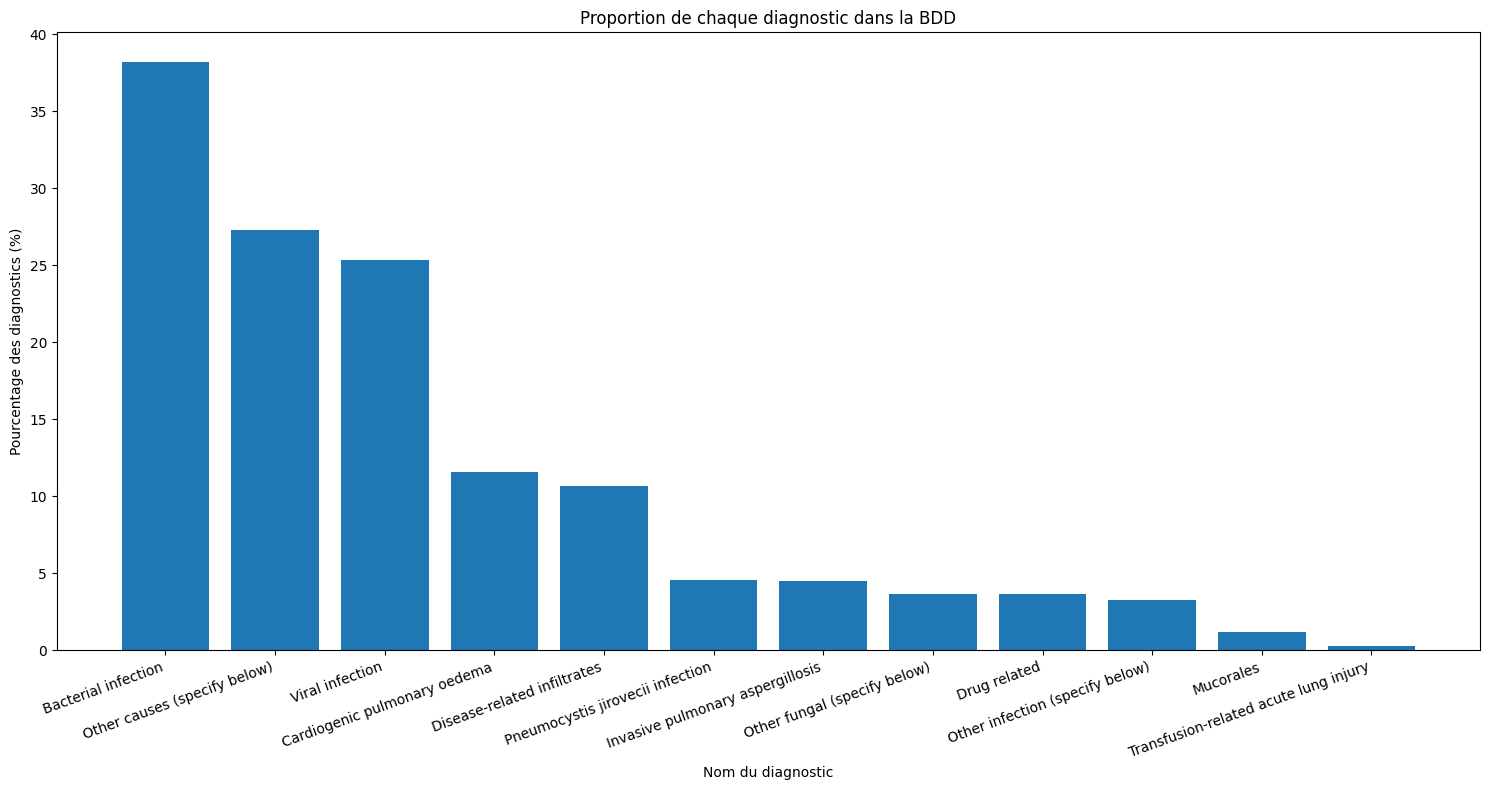

In [4]:
from utils.stats_dataset import analyser_variables_binaires,analyser_associations_binaires
distribution, nb_lignes = analyser_variables_binaires(df_cat_clean)

Nombre de lignes contenant plus d’un '1' : 2383

Associations les plus fréquentes (% des lignes totales) :
                                         Association  Fréquence  Pourcentage
0             (Bacterial infection, Viral infection)        645         8.90
1  (Bacterial infection, Other causes (specify be...        634         8.74
2    (Other causes (specify below), Viral infection)        366         5.05
3  (Bacterial infection, Disease-related infiltra...        251         3.46
4  (Bacterial infection, Cardiogenic pulmonary oe...        239         3.30


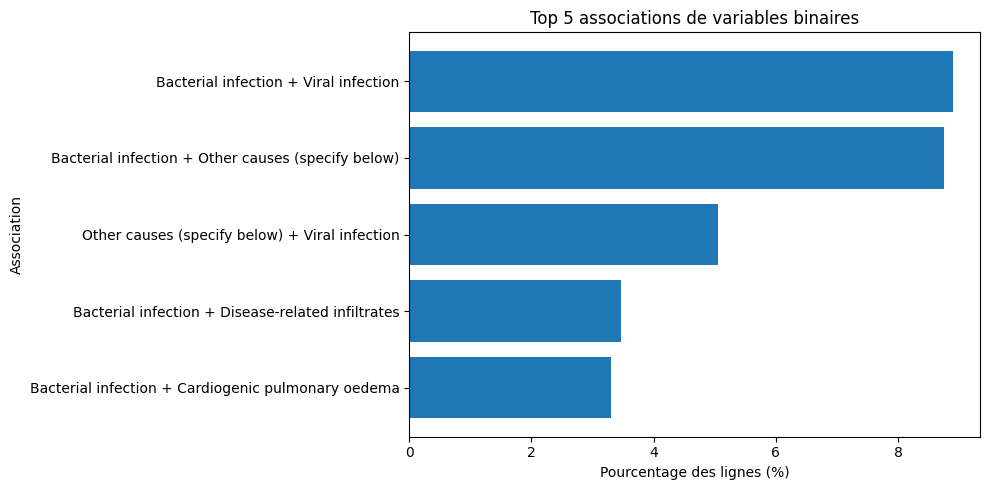

In [5]:
assoc_df, lignes_multi = analyser_associations_binaires(df_cat_clean, top_n=5)

Nombre de lignes totalement vides : 1627


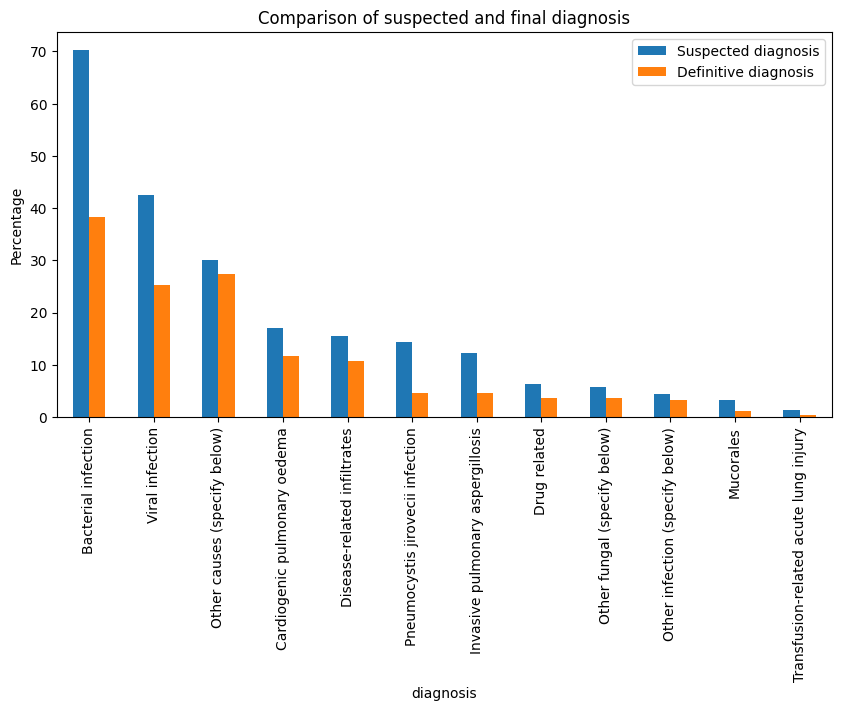

In [6]:

features_suspected = [col.replace("Definitive diagnosis", "Suspected at ICU adm") for col in features_etiology]
df_suspected = df[features_suspected]
df_suspected = nettoyer_colonnes(df_suspected)
df_suspected = nettoyer_lignes_vides(df_suspected)
distribution_suspected, nb_lignes = analyser_variables_binaires(df_suspected,print_results=False,visualisation=False)
distribution_diagnostique, nb_lignes = analyser_variables_binaires(df_cat_clean,print_results=False,visualisation=False)
import matplotlib.pyplot as plt
df_stats_suspected_vs_definitive = pd.concat([distribution_suspected, distribution_diagnostique], axis=1)
df_stats_suspected_vs_definitive.columns = ['Suspected diagnosis','Definitive diagnosis']

df_stats_suspected_vs_definitive.plot(kind='bar', figsize=(10, 5))
plt.xlabel('diagnosis')
plt.ylabel('Percentage')
plt.title('Comparison of suspected and final diagnosis')
plt.legend()
plt.show()


In [5]:
df_features_clean = df_features_clean.loc[df_cat_clean.index]
df_clean = pd.concat([df_features_clean,df_cat_clean], axis=1)

# Aucun prophilaxy et diagnostique

In [ ]:

cond_proph = df_clean["Prophylaxis_antifungal"] == 1

cond_fungal = (
    (df_clean["Mucorales"] == 1) |
    (df_clean["Other fungal (specify below)"] == 1) |
    (df_clean["Invasive pulmonary aspergillosis"] == 1)
)

ean = df_clean[cond_proph & cond_fungal]
# Nombre total
n_total_proph = cond_proph.sum()
n_total_fungal = cond_fungal.sum()
n_both = (cond_proph & cond_fungal).sum()

# Pourcentages
pct_proph = n_both / n_total_proph * 100 if n_total_proph > 0 else 0
pct_fungal = n_both / n_total_fungal * 100 if n_total_fungal > 0 else 0
print("=== Résultats ===")
print(f"Nombre total de patients : {len(df_clean)}")
print(f"Nombre total prophylaxie antifongique : {n_total_proph}")
print(f"Nombre total infection fongique      : {n_total_fungal}")
print(f"Nombre avec les deux conditions       : {n_both}")

print("\n=== Proportions ===")
print(f"→ Parmi les patients prophylaxés : {pct_proph:.2f}% ont une infection fongique.")
print(f"→ Parmi les patients infectés    : {pct_fungal:.2f}% avaient une prophylaxie.")


=== Résultats ===
Nombre total prophylaxie antifongique : 989
Nombre total infection fongique      : 626
Nombre avec les deux conditions       : 148

=== Proportions ===
→ Parmi les patients prophylaxés : 14.96% ont une infection fongique.
→ Parmi les patients infectés    : 23.64% avaient une prophylaxie.


In [ ]:

cond_proph = df_clean["Prophylaxis_pneumocystis"] == 1

cond_fungal = (
    (df_clean['Pneumocystis jirovecii infection'] == 1 )
)

ean = df_clean[cond_proph & cond_fungal]

print("exemple des lignes avec prophylaxie et diagnostiques : ",ean.index)
# Nombre total
n_total_proph = cond_proph.sum()
n_total_fungal = cond_fungal.sum()
n_both = (cond_proph & cond_fungal).sum()

# Pourcentages
pct_proph = n_both / n_total_proph * 100 if n_total_proph > 0 else 0
pct_fungal = n_both / n_total_fungal * 100 if n_total_fungal > 0 else 0
print("=== Résultats ===")
print(f"Nombre total de patients : {len(df_clean)}")
print(f"Nombre total prophylaxie antipneucystis : {n_total_proph}")
print(f"Nombre total pneumocystose    : {n_total_fungal}")
print(f"Nombre avec les deux conditions       : {n_both}")

print("\n=== Proportions ===")
print(f"→ Parmi les patients prophylaxés : {pct_proph:.2f}% ont une pneumocystose.")
print(f"→ Parmi les patients infectés    : {pct_fungal:.2f}% avaient une prophylaxie.")


57 1436 333
Index([ 650,  762,  915,  937, 1108, 1119, 1411, 1880, 2127, 2157, 2317, 2328,
       2372, 2522, 2533, 2686, 2735, 2900, 2980, 2988, 2995, 2996, 3015, 3037,
       3072, 3092, 3141, 3149, 3291, 3387, 3622, 3788, 4075, 4171, 4555, 4668,
       4716, 4753, 4761, 4885, 4892, 5011, 5037, 5038, 5057, 5082, 5359, 5398,
       5494, 5747, 5796, 6270, 6836, 8481, 8598, 8979, 9392],
      dtype='int64')
=== Résultats ===
Nombre total de patients : 7251
Nombre total prophylaxie antipneucystis : 1436
Nombre total pneumocystose    : 333
Nombre avec les deux conditions       : 57

=== Proportions ===
→ Parmi les patients prophylaxés : 3.97% ont une pneumocystose.
→ Parmi les patients infectés    : 17.12% avaient une prophylaxie.


# Colinearite

🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 2164
Nombre de lignes totalement vides : 0


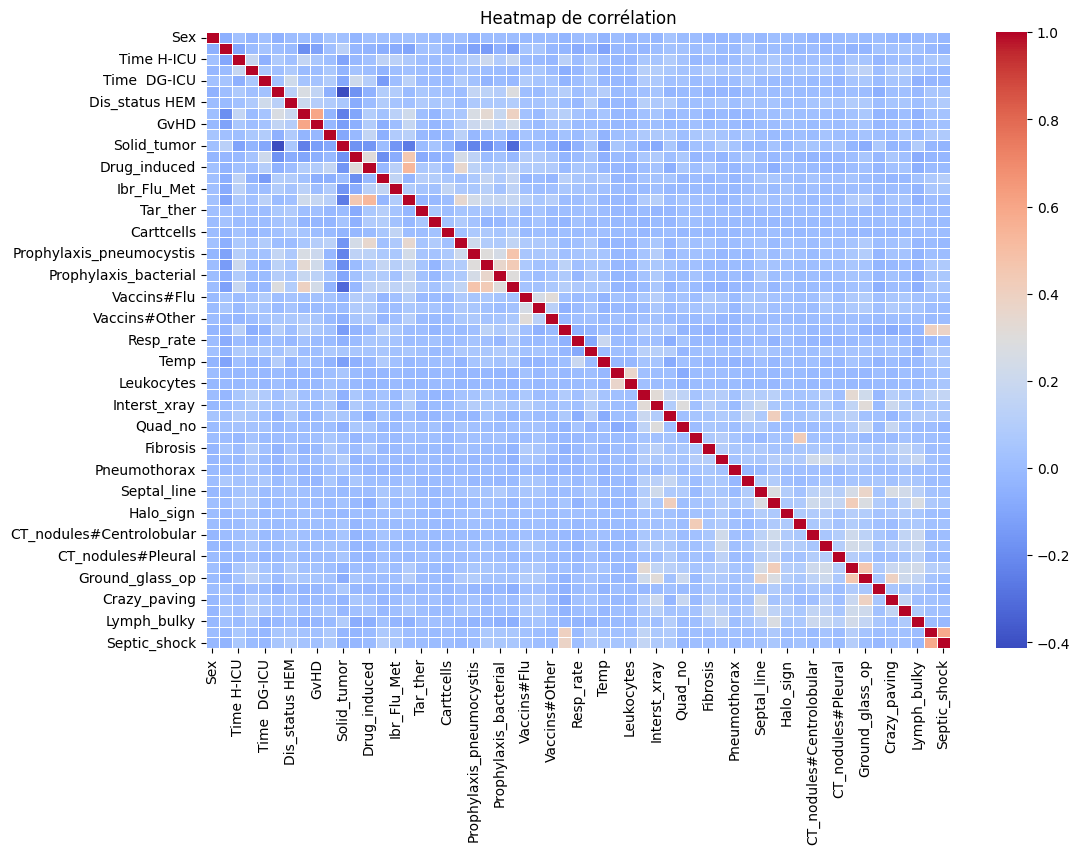


📌 Paires de features fortement corrélées (>|0.7|) :
Aucune corrélation forte détectée.

📌 VIF des features :
                           feature        VIF
30                            Temp  70.284494
1                              Age  21.626218
29                            SpO2  20.268927
28                       Resp_rate  15.577671
27                      SOFA_score   7.541671
36                         Quad_no   6.139103
55                    Vasopressors   3.731935
6                   Dis_status HEM   2.946459
10                     Solid_tumor   2.619067
15                    Immuno_drugs   2.535369
56                    Septic_shock   2.534558
33                   Alveolar_xray   2.491790
49                   Alveolar_cons   2.411976
34                    Interst_xray   2.392189
12                    Drug_induced   2.357967
50                 Ground_glass_op   2.347903
7                         HSCT_BMT   2.311336
43                  CT_Pleural_eff   2.294891
23              

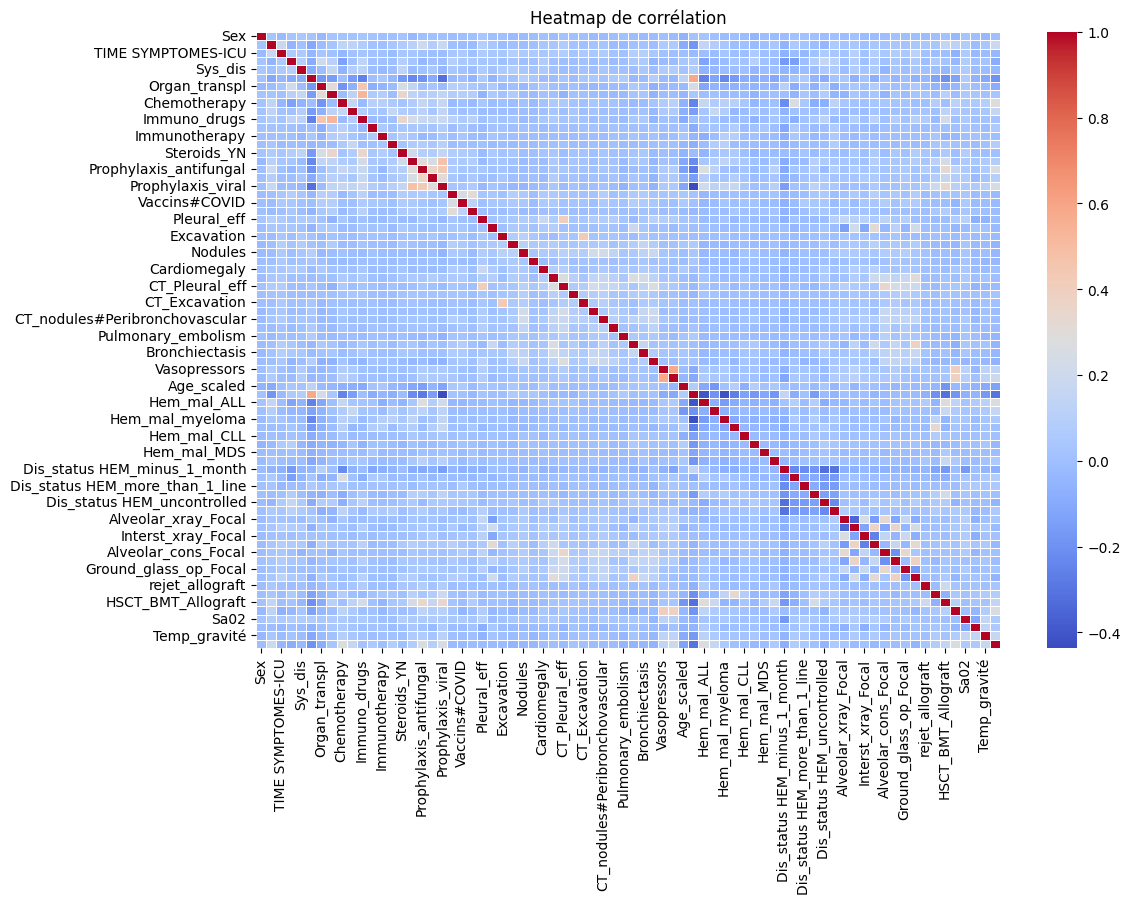


📌 Paires de features fortement corrélées (>|0.7|) :
Aucune corrélation forte détectée.

📌 VIF des features :
                         feature        VIF
70                          Sa02  20.105127
43                   Hem_mal_AML  16.713234
42                    Age_scaled  11.461775
69                   SOFA_scaled   7.387693
52  Dis_status HEM_minus_1_month   6.955050
..                           ...        ...
36            Pulmonary_embolism   1.077671
13                    Carttcells   1.069325
31                     Halo_sign   1.062437
66               rejet_allograft   1.056675
27                  Pneumothorax   1.042088

[74 rows x 2 columns]


In [7]:
from utils.stats_dataset import analyze_collinearity
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
Liste_features = Liste_features_simple + features_radiology_dysfunction
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
df_col_utils = _convert_all_columns_to_numeric(df_col_utils)
# print(df_col_utils.columns)

df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)

df_category = nettoyer_colonnes(df_category)
df_cat_clean = nettoyer_lignes_vides(df_category)
df_col_utils = nettoyer_lignes_vides(df_col_utils)
vif_results = analyze_collinearity(df_col_utils)
vif_results_clean = analyze_collinearity(df_features_clean)



In [26]:
for index, row in vif_results_clean.iterrows():
    
    if row['VIF'] > 2:
        print(f"Feature '{row['feature']}' has a high VIF of {row['VIF']:.2f}, indicating potential multicollinearity.")
        print(df_features_clean.corr()[row['feature']].abs().sort_values(ascending=False)[:3])


Feature 'Sa02' has a high VIF of 20.11, indicating potential multicollinearity.
Sa02                            1.000000
Dis_status HEM_minus_1_month    0.167835
Temp_gravité                    0.162818
Name: Sa02, dtype: float64
Feature 'Hem_mal_AML' has a high VIF of 16.71, indicating potential multicollinearity.
Hem_mal_AML          1.000000
Solid_tumor          0.583108
Prophylaxis_viral    0.436350
Name: Hem_mal_AML, dtype: float64
Feature 'Age_scaled' has a high VIF of 11.46, indicating potential multicollinearity.
Age_scaled                      1.000000
HSCT_BMT_Allograft              0.184506
Hem_mal_Non_hodgkin_lymphoma    0.178149
Name: Age_scaled, dtype: float64
Feature 'SOFA_scaled' has a high VIF of 7.39, indicating potential multicollinearity.
SOFA_scaled     1.000000
Vasopressors    0.400826
Septic_shock    0.380640
Name: SOFA_scaled, dtype: float64
Feature 'Dis_status HEM_minus_1_month' has a high VIF of 6.96, indicating potential multicollinearity.
Dis_status HEM_minu

In [18]:
import sys 
sys.modules.pop('utils.visualisation',None)

<module 'utils.visualisation' from 'c:\\Users\\romai\\Desktop\\codes\\respiratory_diagnostics\\utils\\visualisation.py'>

# Scikit multilearn

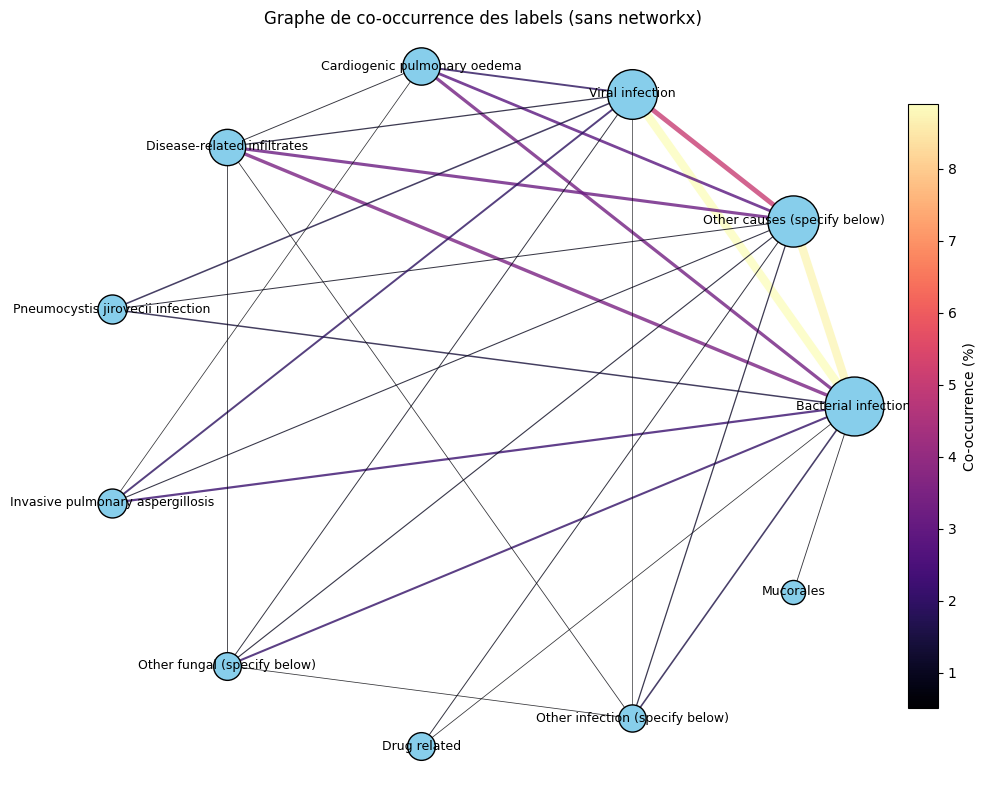

In [19]:
from utils.visualisation import plot_multilabel_cooccurrence

# df_cat_clean = votre Y one-hot
from utils.visualisation import plot_multilabel_network_matplotlib
fig, ax = plot_multilabel_network_matplotlib(
    df_cat_clean,
    min_support=0.01,   # garde labels présents dans >=1% des lignes
    top_k=20,           # prend les 20 plus fréquents
    normalize="percent",
    edge_threshold=0.5, # n’affiche que co-occurrences >= 0.5%
    annot_edges=False,
    annot_nodes=True,
)
plt.show()

In [16]:
import networkx

AttributeError: 'wrapper_descriptor' object has no attribute '__annotate__'